## Work done by: Mohammad Al-Refaie

In [1]:
import datetime
import matplotlib.pyplot as plt
from pyspark import SparkContext
sc=SparkContext(master='local')

### Task 1: Find the number of flights per day that land at "Istanbul Ataturk Airport" in March 2024. Print the results.

In [2]:
#Solution
FlightsRDD=sc.textFile(r"C:\Users\Mohammad Husam\OneDrive\Desktop\TTU\Big Data\Slides 2\Coding\trip.txt") 
IstanbulRDD=FlightsRDD.filter(lambda x: x.split(',')[3] == 'Istanbul Ataturk Airport')
DateRDD=IstanbulRDD.filter(lambda x: datetime.datetime.strptime(x.split(',')[5], '%Y-%m-%d %H:%M:%S').date().month == 3)
MappedDate=DateRDD.map(lambda x:(datetime.datetime.strptime(x.split(',')[5],'%Y-%m-%d %H:%M:%S').date(),1))
ResultDataRDD=MappedDate.reduceByKey(lambda x,y: x+y)

ResultDataRDD.collect()

[(datetime.date(2024, 3, 17), 215),
 (datetime.date(2024, 3, 24), 242),
 (datetime.date(2024, 3, 19), 225),
 (datetime.date(2024, 3, 8), 245),
 (datetime.date(2024, 3, 11), 210),
 (datetime.date(2024, 3, 21), 227),
 (datetime.date(2024, 3, 7), 210),
 (datetime.date(2024, 3, 25), 227),
 (datetime.date(2024, 3, 29), 211),
 (datetime.date(2024, 3, 23), 228),
 (datetime.date(2024, 3, 30), 232),
 (datetime.date(2024, 3, 4), 236),
 (datetime.date(2024, 3, 18), 213),
 (datetime.date(2024, 3, 16), 217),
 (datetime.date(2024, 3, 13), 214),
 (datetime.date(2024, 3, 9), 208),
 (datetime.date(2024, 3, 5), 265),
 (datetime.date(2024, 3, 6), 217),
 (datetime.date(2024, 3, 15), 218),
 (datetime.date(2024, 3, 14), 195),
 (datetime.date(2024, 3, 28), 208),
 (datetime.date(2024, 3, 22), 214),
 (datetime.date(2024, 3, 10), 216),
 (datetime.date(2024, 3, 20), 237),
 (datetime.date(2024, 3, 27), 202),
 (datetime.date(2024, 3, 12), 240),
 (datetime.date(2024, 3, 31), 239),
 (datetime.date(2024, 3, 3), 199),

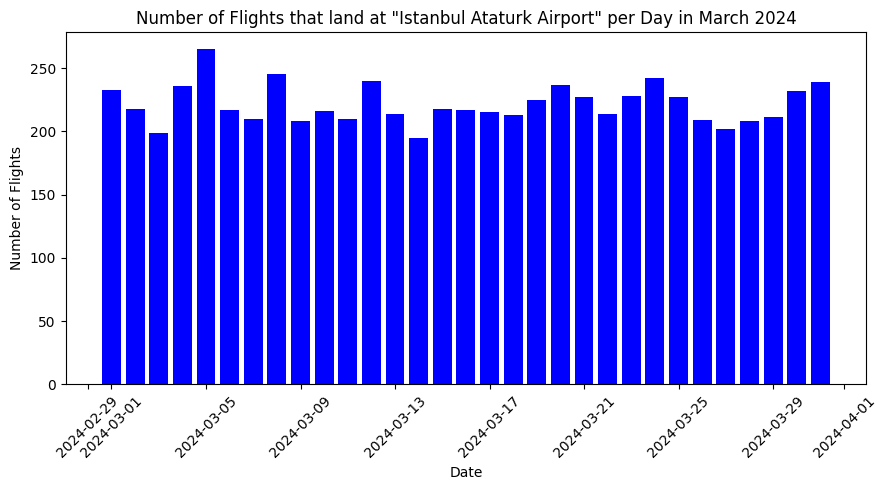

In [3]:
#Adding some visualization
DatesRDD=ResultDataRDD.map(lambda x: x[0]).collect()
FlightsNumRDD=ResultDataRDD.map(lambda x: x[1]).collect()

plt.figure(figsize=(9, 5))
plt.bar(DatesRDD, FlightsNumRDD, color='blue')
plt.xlabel('Date')
plt.ylabel('Number of Flights')
plt.title('Number of Flights that land at "Istanbul Ataturk Airport" per Day in March 2024')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


## ─────────────────────────────────────────────────

### Task 2: Find the flights landing at "Phoenix Sky Harbor International Airport" between 10:00 and 20:00. Store the results in a file.

In [4]:
#Solution
FlightsRDD2=sc.textFile(r"C:\Users\Mohammad Husam\OneDrive\Desktop\TTU\Big Data\Slides 2\Coding\trip.txt") 
PhoenixRDD=FlightsRDD2.filter(lambda x: x.split(',')[3]=='Phoenix Sky Harbor International Airport')
LandTimeRDD=PhoenixRDD.filter(lambda x: 10 <= datetime.datetime.strptime(x.split(',')[5], '%Y-%m-%d %H:%M:%S').time().hour <= 20)

LandTimeRDD.saveAsTextFile("Phoenix_Sky_Harbor_International_Airport_flights.txt")

In [5]:
#A sample from the result
LandTimeRDD.take(4)

['2024-04-17 17:20:32,Los Angeles International Airport,LAX,Phoenix Sky Harbor International Airport,PHX,2024-04-17 17:59:32,Turkish Airlines,595Km,Boeing 737-300,148,143',
 '2024-05-01 05:40:09,Charles de Gaulle Airport,CDG,Phoenix Sky Harbor International Airport,PHX,2024-05-01 15:27:09,Air France,8809Km,Airbus A319,150,143',
 '2024-03-01 01:00:25,Soekarno-Hatta International Airport,CGK,Phoenix Sky Harbor International Airport,PHX,2024-03-01 17:41:25,Air Canada,15023Km,Embraer ERJ170,76,66',
 '2024-01-10 04:42:30,Shanghai Pudong International Airport,PVG,Phoenix Sky Harbor International Airport,PHX,2024-01-10 16:48:30,Air Canada,10893Km,Airbus A321,210,206']

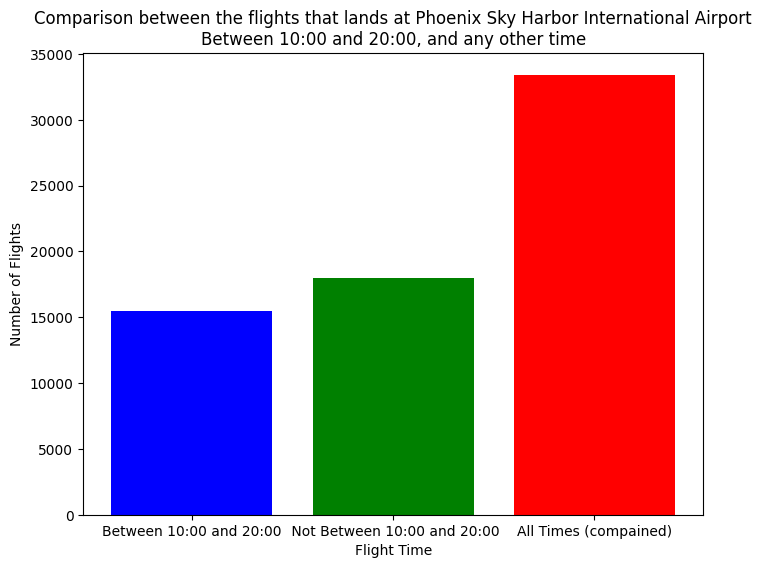

In [6]:
#Adding some visualization
AnyTimeRDD=PhoenixRDD.filter(lambda x: not(10 <= datetime.datetime.strptime(x.split(',')[5], '%Y-%m-%d %H:%M:%S').time().hour <= 20))
AnyOtherTime=AnyTimeRDD.count()
TheTaskRange=LandTimeRDD.count()
AllTimes=PhoenixRDD.count()

Labels=['Between 10:00 and 20:00', ' Not Between 10:00 and 20:00', 'All Times (compained)']
Counts=[TheTaskRange, AnyOtherTime, AllTimes]
plt.figure(figsize=(8, 6))
plt.bar(Labels, Counts, color=['blue', 'green', 'red'])
plt.xlabel('Flight Time')
plt.ylabel('Number of Flights')
plt.title('Comparison between the flights that lands at Phoenix Sky Harbor International Airport\nBetween 10:00 and 20:00, and any other time')
plt.show()

## ─────────────────────────────────────────────────

### Task 3: Find all "Air France" flights that land at "Kuala Lumpur International Airport" and store the results in a file. 

In [7]:
#Solution
FlightsRDD3=sc.textFile(r"C:\Users\Mohammad Husam\OneDrive\Desktop\TTU\Big Data\Slides 2\Coding\trip.txt") 
AirFranceRDD=FlightsRDD3.filter(lambda x: x.split(',')[6]=='Air France' and x.split(',')[3]=='Kuala Lumpur International Airport')

AirFranceRDD.saveAsTextFile("Air_France_info.txt")

In [8]:
#A sample from the result
AirFranceRDD.take(4)

['2024-03-21 01:47:26,Guangzhou Baiyun International Airport,CAN,Kuala Lumpur International Airport,KUL,2024-03-21 04:41:26,Air France,2615Km,Airbus A320,180,173',
 '2024-05-12 01:05:32,Shanghai Pudong International Airport,PVG,Kuala Lumpur International Airport,KUL,2024-05-12 05:18:32,Air France,3800Km,Boeing 737-700,148,146',
 '2024-04-05 16:08:44,Denver International Airport,DEN,Kuala Lumpur International Airport,KUL,2024-04-06 08:20:44,Air France,14583Km,AVRO RJ100,112,107',
 '2024-05-15 01:24:22,Hartsfield-Jackson Atlanta International Airport,ATL,Kuala Lumpur International Airport,KUL,2024-05-15 19:06:22,Air France,15936Km,Boeing 737-700,148,143']

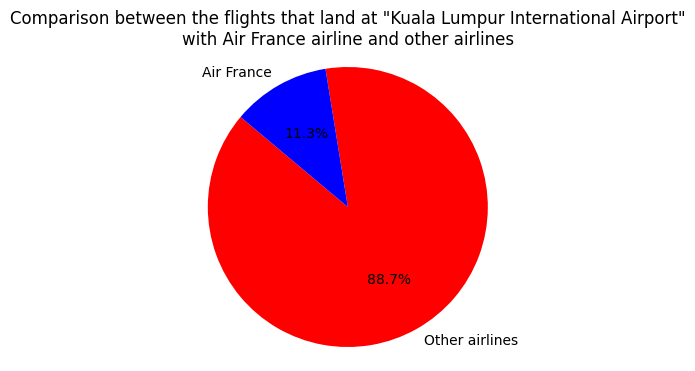

In [9]:
#Adding some Visualization
OtherAirLinesRDD=FlightsRDD3.filter(lambda x: x.split(',')[6] != 'Air France' and x.split(',')[3] == 'Kuala Lumpur International Airport')
AirLinesCounter=OtherAirLinesRDD.count()
AirFranceCounter=AirFranceRDD.count()

Labels=['Other airlines', 'Air France']
Counts=[AirLinesCounter, AirFranceCounter]
Colors=['red', 'blue']
plt.figure(figsize=(6, 4))
plt.pie(Counts, labels=Labels, colors=Colors, autopct='%1.1f%%', startangle=140)
plt.title('Comparison between the flights that land at "Kuala Lumpur International Airport"\nwith Air France airline and other airlines')
plt.axis('equal')
plt.show()

## ─────────────────────────────────────────────────

### Task 4: Find the number of overnight flights per month in 2024. The term "overnight flights" refers to flights that depart between 20:00 and 23:00 and arrive the next day after 03:00. Store the results in a file. 

In [10]:
#Solution
FlightsRDD4=sc.textFile(r"C:\Users\Mohammad Husam\OneDrive\Desktop\TTU\Big Data\Slides 2\Coding\trip.txt") 
OverNightRDD=FlightsRDD4.filter(lambda x: 20 <= datetime.datetime.strptime(x.split(',')[0], '%Y-%m-%d %H:%M:%S').time().hour <= 23
                                 and datetime.datetime.strptime(x.split(',')[5], '%Y-%m-%d %H:%M:%S').date() >
                                 datetime.datetime.strptime(x.split(',')[0], '%Y-%m-%d %H:%M:%S').date()
                                 and datetime.datetime.strptime(x.split(',')[5], '%Y-%m-%d %H:%M:%S').time().hour > 3)

PairedFlightsRDD=OverNightRDD.map(lambda x:(datetime.datetime.strptime(x.split(',')[0], '%Y-%m-%d %H:%M:%S').month, 1))
ReducedPair=PairedFlightsRDD.reduceByKey(lambda x,y: x+y)

ReducedPair.saveAsTextFile("Over_Night_Flights.txt")

In [11]:
#The full result
ReducedPair.collect()

[(5, 23631), (1, 24259), (2, 22509), (3, 24088), (4, 23565)]

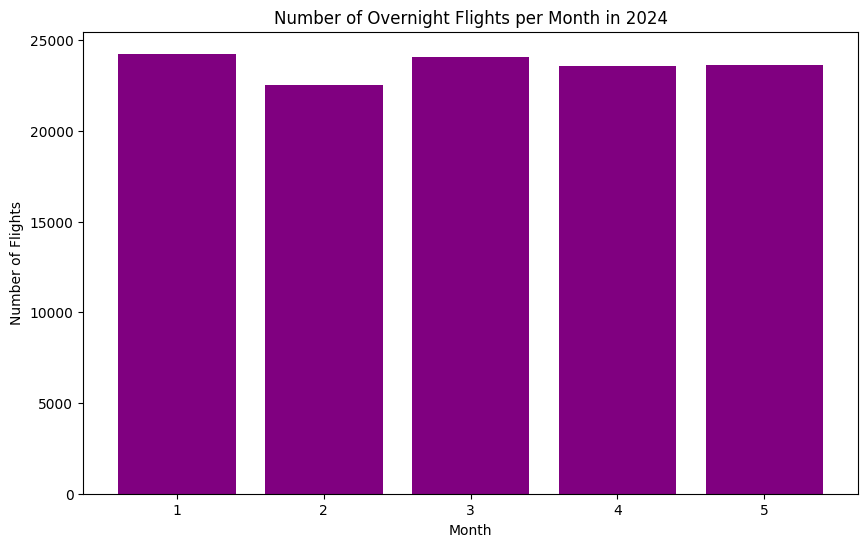

In [12]:
#Adding some Visualization
MonthsRDD=ReducedPair.map(lambda x: x[0]).collect()
CountsRDD=ReducedPair.map(lambda x: x[1]).collect()

plt.figure(figsize=(10, 6))
plt.bar(MonthsRDD, CountsRDD, color='purple')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.title('Number of Overnight Flights per Month in 2024')
plt.xticks(range(1, 6))
plt.show()

## ─────────────────────────────────────────────────

### Task 5: Find the occupancy rate for each "Qatar Airways" flight in May 2024. Store the results in a file.
### The occupancy rate for a flight refers to the percentage of available seats on an aircraft that are filled with passengers.  For example, if a plane has 200 seats and there are 180 passengers on board, the occupancy rate would be:
### (180 passengers / 200 seats) * 100 = 90% occupancy rate

In [19]:
#Solution
FlightsRDD5=sc.textFile(r"C:\Users\Mohammad Husam\OneDrive\Desktop\TTU\Big Data\Slides 2\Coding\trip.txt")
QatarRDD=FlightsRDD5.filter(lambda x: x.split(',')[6] == 'Qatar Airways') 
MayFlights=QatarRDD.filter(lambda x: datetime.datetime.strptime(x.split(',')[0], '%Y-%m-%d %H:%M:%S').date().month == 5)
OccupancyRDD=MayFlights.map(lambda x: (x.split(',')[0], x.split(',')[6], str(round(int(x.split(',')[10]) / int(x.split(',')[9]) * 100, 2)) + ' %'))

OccupancyRDD.saveAsTextFile("Qatar_Airways_Occupancy.txt")

In [20]:
#A sample from the result
OccupancyRDD.take(10)

[('2024-05-28 01:39:59', 'Qatar Airways', '97.37 %'),
 ('2024-05-05 13:08:23', 'Qatar Airways', '98.1 %'),
 ('2024-05-25 20:38:00', 'Qatar Airways', '96.67 %'),
 ('2024-05-27 21:24:55', 'Qatar Airways', '97.62 %'),
 ('2024-05-24 12:14:35', 'Qatar Airways', '93.75 %'),
 ('2024-05-16 15:42:53', 'Qatar Airways', '98.1 %'),
 ('2024-05-06 20:40:44', 'Qatar Airways', '97.71 %'),
 ('2024-05-02 17:34:51', 'Qatar Airways', '98.1 %'),
 ('2024-05-20 19:43:14', 'Qatar Airways', '95.0 %'),
 ('2024-05-11 09:05:48', 'Qatar Airways', '96.05 %')]

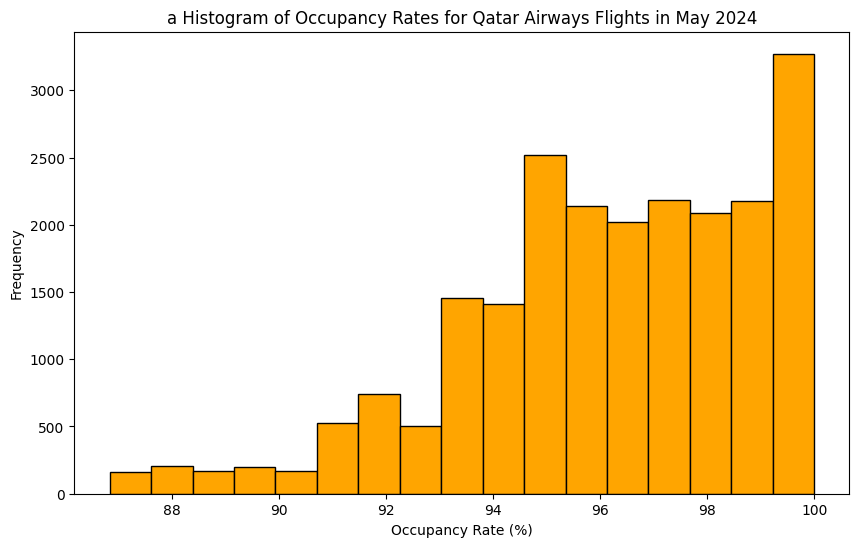

In [21]:
#Adding some Visualization
OccupancyExtract=OccupancyRDD.map(lambda x: float(x[2].strip('%'))).collect()

plt.figure(figsize=(10, 6))
plt.hist(OccupancyExtract, bins=17, color='orange', edgecolor='black')
plt.xlabel('Occupancy Rate (%)')
plt.ylabel('Frequency')
plt.title('a Histogram of Occupancy Rates for Qatar Airways Flights in May 2024')
plt.show()
